# <center> Livrable 4
## <center> Escape no game
###### <center> BRÉHÉRET Lucas, MAPANGOU - MAGAMBOU Tychique, MAGNIER Alexis, NORMAND Maëlyne


In [157]:
!pip install numpy
!pip install matplotlib
!pip install scipy

In [158]:
import numpy as np
import math
from matplotlib import pyplot as plt
from scipy.signal import hilbert
import scipy.fftpack

## Message

Les message que nous voulons transmettre

In [159]:
message = "AbCdEfGhUjKlMnOpQrStUvWxYz1234567890"

## Conversion en binaire du message

Nous enregistrons le message binaire sous la forme d'un tableau d'entiers.

 - La fonction `format` permet de convertir un entier en une chaine de caractère le représentant en binaire.
 - La fonction `ord` nous donne l'identifiant d'un charactère dans la table ASCII

In [160]:
bin_message = []
for c in message:
    bin_message.append([int(b) for b in format(ord(c), '08b')])

## Encodage des fréqences


In [ ]:
# La fréquence d'échentillonage
SAMPLING_FREQUENCY = 44100

# La fréquence de base du signal encodé
BASE_FREQUENCY = 10

# La fréquence de transmition (caractères / seconde)
TRANSMIT_FREQUENCY = 10

# La péride de la transmition
TRANSMIT_PERIOD = 1 / TRANSMIT_FREQUENCY

# Le nombre d'échantillons pas caractères
SAMPLES_PER_SIGNAL = int(SAMPLING_FREQUENCY * TRANSMIT_PERIOD)

t = np.linspace(0, TRANSMIT_PERIOD, SAMPLES_PER_SIGNAL, dtype=np.float32)
signals = []

# Pour chacun des charactères binaires
for i in range(len(bin_message)):

    # Générer un signal vide
    signals.append(np.zeros(SAMPLES_PER_SIGNAL))
    c = bin_message[i]
    
    # Pour chaqun des bits de caractères
    for j in range(len(c)):
        b = c[j]

        # Si le bit est 0, on l'ignore
        if b == 0:
            continue
        
        # Si il est 1, nous ajoutons une sinosïdale de la fréquence du bit au signal
        signals[i] += np.sin(2 * np.pi * BASE_FREQUENCY * (j+1) * t)
    
    # Nous normalisons le signal
    signals[i] /= np.max(signals[i])

Nous pouvons afficher les signaux

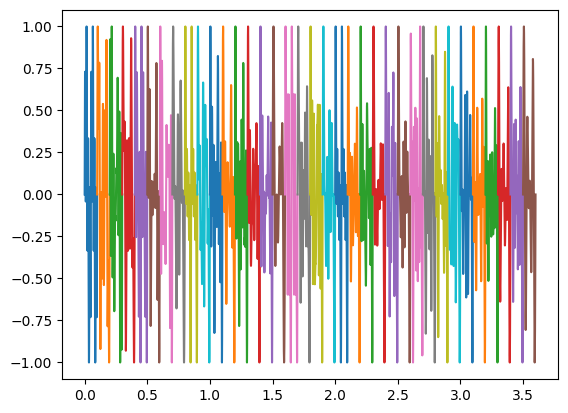

In [ ]:
for i in range(len(signals)):
    s = signals[i]
    start = i * TRANSMIT_PERIOD

    plt.plot(t + TRANSMIT_PERIOD * i, s)
plt.show()

## Modulation



In [163]:
# Les caractéristiques de la porteuse
CARRIER_FREQUENCY = 5000
CARRIER_DEVIATION = 1000

modulated_signals = []

# Pour tout les signaux modulés
for i in range(len(signals)):
    s = signals[i]

    # Nous faisons l'intégral du signal
    integral = np.cumsum(s) / SAMPLING_FREQUENCY

    # Et nous construisons le signal modulé FM
    fm_signal = np.cos(2 * np.pi * CARRIER_FREQUENCY * t + 2 * np.pi * CARRIER_DEVIATION * integral, dtype=np.float32)

    # Nous l'ajoutons au tableau des signaux modulés
    modulated_signals.append(fm_signal)

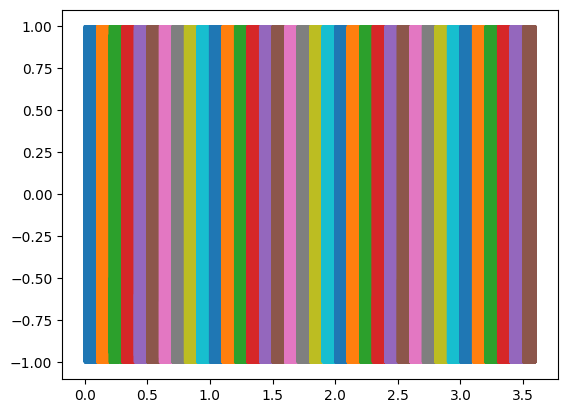

In [164]:
for i in range(len(signals)):
    s = modulated_signals[i]
    start = i * TRANSMIT_PERIOD

    plt.plot(t + TRANSMIT_PERIOD * i, s)
plt.show()

## Transmition

Nous supposerons ici qu'un signal serait envoyé et reçu.
Pour simuler les imprécisions de l'enceinte et du micro, nous rajouterons du bruit

In [165]:
# La quantité de bruit
NOISE_RANGE = (0, 4*10e-2)

received_signal = []
for s in modulated_signals:
    noise = np.random.normal(NOISE_RANGE[0], NOISE_RANGE[1], SAMPLES_PER_SIGNAL)
    received_signal.extend(s + noise)

# Normalize
received_signal /= np.max(received_signal)

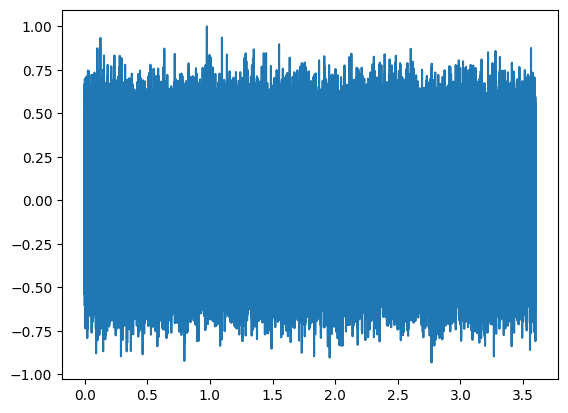

In [166]:
plt.plot(np.linspace(0, TRANSMIT_PERIOD * len(message), SAMPLES_PER_SIGNAL * len(message)), received_signal)
plt.show()

## Démodulation

In [172]:
# Tout d'abord, nous découpons le message reçu en ses caractères
character_signals = received_signal.reshape(int(len(received_signal) / SAMPLES_PER_SIGNAL), SAMPLES_PER_SIGNAL)

demodulated_signals = []

# Pour chaque caractères modulé
for i in range(len(character_signals)):
    s = character_signals[i]

    # Construisons le signal analytique s_H(t) = s(t) + jH(s(t))
    analytic_signal = hilbert(s)
    
    # Nous construisons un tableau des temps correspondans au signal reçu (Nous nous pouvons pas simplement utiliser le même qu'avant du à des échantillons perdu lors de la récéption)
    t = np.linspace(0, len(s) / SAMPLING_FREQUENCY, len(s), endpoint=False)  # Ensure t matches s

    # À l'aide du signal analytique, nous pouvons déterminer la phase
    instantaneous_phase = np.unwrap(np.angle(analytic_signal))

    # Ensuite, nous retirons la porteuse du signal
    residual_phase = instantaneous_phase - 2 * np.pi * CARRIER_FREQUENCY * t

    # Puis en dérivons pour retrouver le signal encodé
    demodulated_derivative = np.gradient(residual_phase, t)

    # Enfin, nous normalisons
    demodulated = demodulated_derivative / (2 * np.pi * TRANSMIT_FREQUENCY)
    demodulated_signals.append(demodulated)


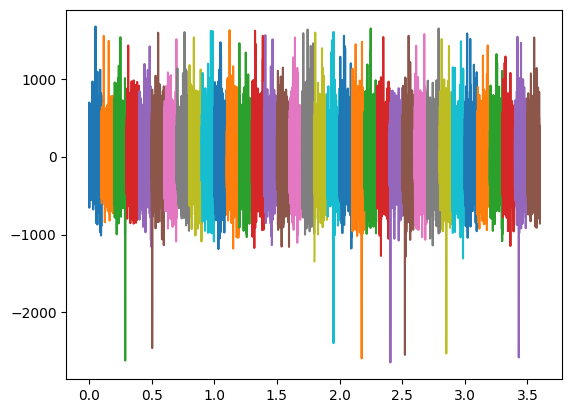

In [173]:
for i in range(len(demodulated_signals)):
    t = np.linspace(0, len(s) / SAMPLING_FREQUENCY, len(s), endpoint=False)  # Ensure t matches s

    demodulated = demodulated_signals[i]

    plt.plot(t + i * TRANSMIT_PERIOD, demodulated)
plt.show()

## Décodage

Tout d'abord, nous effectuons une transformé de fourrier afin de décomposer le signal en ses fréquences.
Étant donné que nous avons ajouté du bruit, il y a un filtre à réaliser.

Nous supposerons qu'un bit est transmis seuelement si la magnétude de sa fréquence est supérieure à la moyenne entre la valeur la plus faible du signal et la valeur la plus élevé.

In [174]:
receives_bin_message = []

# Pour tout les signaux démodulés
for i in range(len(demodulated_signals)):

    # Aquérir les fréquences
    fft_data = np.abs(np.fft.rfft(demodulated_signals[i]))

    # Les indices des fréquences
    freqs = np.fft.rfftfreq(SAMPLES_PER_SIGNAL, d=1/SAMPLING_FREQUENCY)
    
    # Le seul à partir du quel, nous suppossons qu'un bit est transit
    treshold = (np.max(fft_data) + np.min(fft_data)) / 2
    
    bits = []

    # Pour chaques bits, nous vérifions si la magnétude de la fréquence est supérieure au seuil
    for j in range(1, 9):
        frequency = j * BASE_FREQUENCY
        index = np.argmin(np.abs(freqs - frequency))

        # Si il est supérieur
        if fft_data[index] > treshold:
            bits.append(1)
        
        # Si il n'est pas détécté
        else:
            bits.append(0)
    
    # Enfin, nous ajoutons le caractère que nous venons de décoder au message
    receives_bin_message.append(bits)


Afin de vérifier la fiabilité du système. Nous effectuons une comparaison entre le signal originel et celui décodé.

In [175]:

receives_bin_message = np.array(receives_bin_message)
bin_message = np.array(bin_message)

equal_count = 0
for i in range(len(receives_bin_message)):
    for j in range(8):
        if receives_bin_message[i, j] == bin_message[i, j]:
            equal_count += 1

similarity = equal_count / (len(receives_bin_message) * 8)
loss = 1-similarity
print(f"La transmition a {loss*100}% de perte")


La transmition a 0.0% de perte


## Conversion en texte

Pour convertir en texte, nous additionons les bits pour obtenir l'index ASCII du caractère, puis nous ajoutons le caractère au message final

In [176]:
received_message = ""

for bits in receives_bin_message:
    byte_value = int("".join(map(str, bits)), 2)
    char = chr(byte_value)

    received_message += char

print(received_message)


AbCdEfGhUjKlMnOpQrStUvWxYz1234567890
